In [1]:
# cnn 이미지 분류 실습

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
import joblib
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# 데이터 가져오기
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# 클래스 이름 정의
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal",
    "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("X_train shape : ", X_train.shape)
print("X_test shape : ", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape :  (60000, 28, 28)
X_test shape :  (10000, 28, 28)


In [16]:
# 데이터 정규화

# 픽셀값 0~1 범위로 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

# cnn 입력 형태에 맞게 채녈 차원을 reshape
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


In [5]:
# 모델 정의
model = Sequential()   # 순차형 신경망 생성

# 첫번째 합성곱(convolution layer) 층을 추가
# activation="relu" → 음수 값은 0으로, 양수는 그대로 통과시켜 중요한 특징만 남김 (비선형성 추가)
model.add(Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)))
# 풀링층 추가
# (2,2,) → 마지막 ,는 튜플 문법/스타일일 뿐이며 없어도 동일하게 동작함
model.add(MaxPooling2D((2,2,)))

# 두번째 합성곱(convolution layer) 층을 추가
model.add(Conv2D(64, (3,3), activation="relu"))
# 풀링층 추가
model.add(MaxPooling2D((2,2,)))

# 1차원 벡터로 펼침
model.add(Flatten())
# 완전 연결층 추가
model.add(Dense(128, activation="relu"))
# dropout 추가
model.add(Dropout(0.3))

# 출력층 추가
# activation="softmax" → 출력값을 확률로 변환하여 각 클래스에 속할 확률을 계산하고, 총합이 1이 되도록 정규화함
model.add(Dense(10, activation="softmax"))

model.summary()

D:\anaconda3\envs\ai\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 모델 컴파일
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [7]:
# 모델 학습
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.7925 - loss: 0.5706 - val_accuracy: 0.8633 - val_loss: 0.3807
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.8660 - loss: 0.3713 - val_accuracy: 0.8817 - val_loss: 0.3262
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.8840 - loss: 0.3194 - val_accuracy: 0.8848 - val_loss: 0.3122
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.8944 - loss: 0.2914 - val_accuracy: 0.8957 - val_loss: 0.2817
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.9025 - loss: 0.2657 - val_accuracy: 0.8999 - val_loss: 0.2741
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9097 - loss: 0.2442 - val_accuracy: 0.9011 - val_loss: 0.2690
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9165 - loss: 0.2273 - val_accuracy: 0.9035 - val_loss: 0.2665
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.9245 - loss: 0.2083 - 

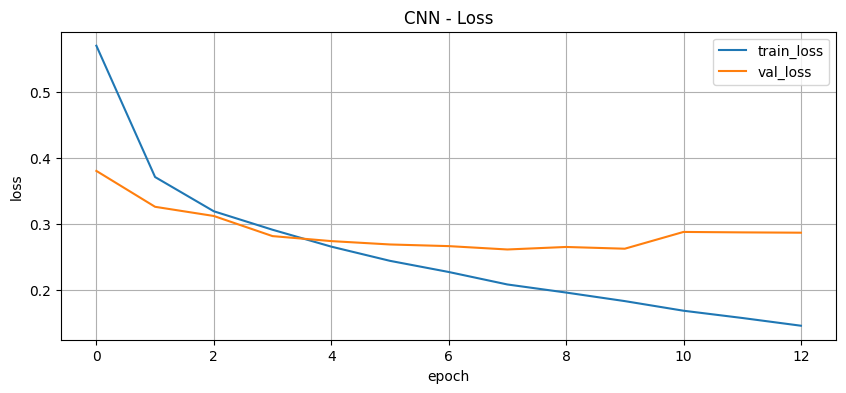

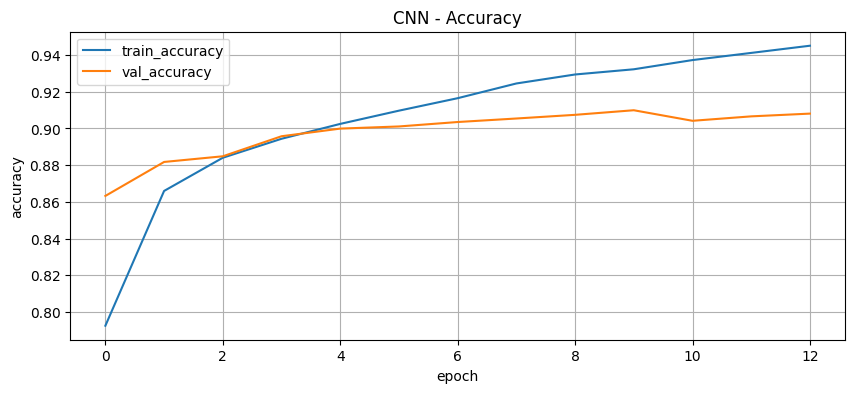

In [8]:
# 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("CNN - Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("CNN - Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# 모델 성능 평가
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("테스트 손실:", test_loss)
print("테스트 정확도:", test_acc)

테스트 손실: 0.27617090940475464
테스트 정확도: 0.9002000093460083


In [10]:
# 예측 확률 계산

# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [17]:
# 학습 결과 저장
model.save("./results/9-03) cnn_fashion_mnist.h5")

# 읽어오기
loaded_model = tf.keras.models.load_model("./results/9-03) cnn_fashion_mnist.h5")

In [12]:
# 신규 데이터 예측/분류
new_images = X_test[:5]

# 신규 이미지 예측
new_prob = loaded_model.predict(new_images)

# 최종 클래스 예측값 계산
new_pred = np.argmax(new_prob, axis=1)

# 예측결과 출력
for i in range(len(new_images)):
    print(f"{i+1}번 이미지 - 예측클래스: {new_pred[i]} ({class_names[new_pred[i]]})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1번 이미지 - 예측클래스: 9 (Ankle boot)
2번 이미지 - 예측클래스: 2 (Pullover)
3번 이미지 - 예측클래스: 1 (Trouser)
4번 이미지 - 예측클래스: 1 (Trouser)
5번 이미지 - 예측클래스: 6 (Shirt)


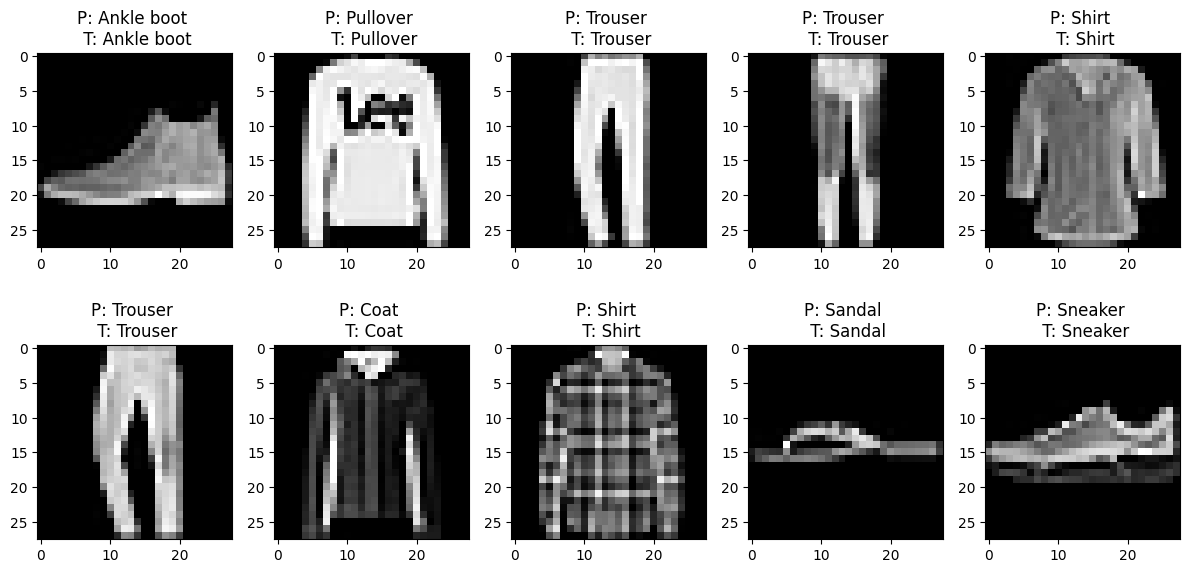

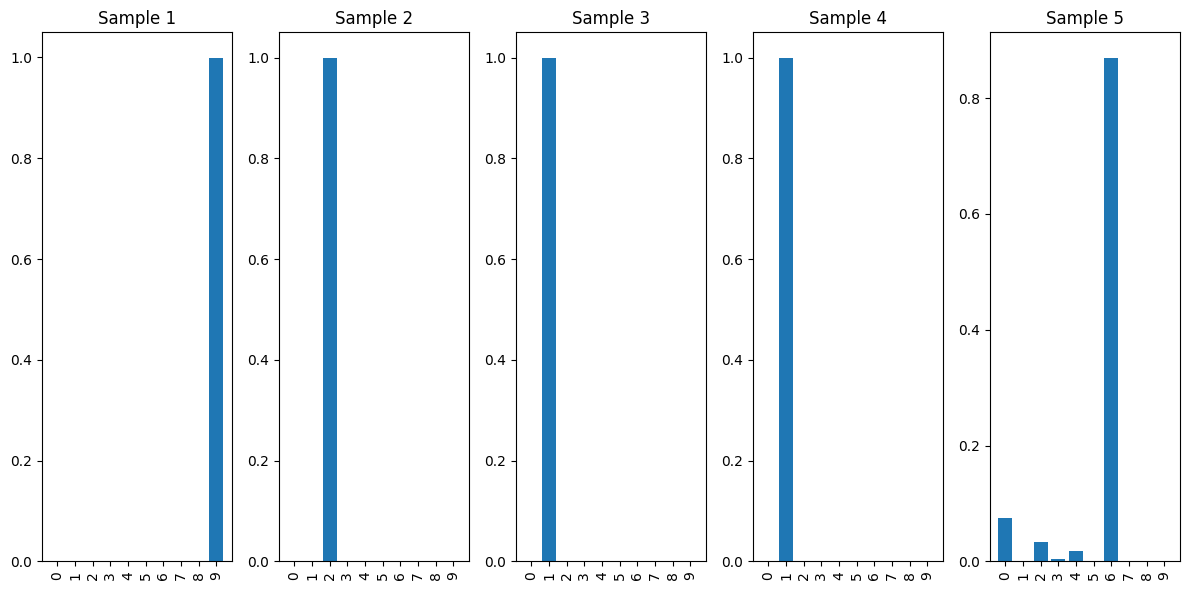

In [13]:
# 예측 결과 시각화 --> 테스트 이미지 10개와 예측 결과 시각화
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title(f"P: {class_names[y_pred[i]]} \n T: {class_names[y_test[i]]}")

plt.tight_layout()
plt.show()

# 신규 이미지 5개에 대한 확률 분포
plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.bar(range(10), new_prob[i])
    plt.title(f"Sample {i+1}")
    plt.xticks(range(10), rotation=90)

plt.tight_layout()
plt.show()